# Stage 8: Multi-Head Sequence Model and Classical Baselines

Stage 7 established that a sequence-aware model (a 1D-CNN over the full MFCC time series) substantially outperforms any static-feature classifier, but predicted the intent as a single flat 31-way classification, following the same label convention used since Stage 5. This stage instead predicts the corpus's three native label slots -- action, object, and location -- as three separate output heads over one shared convolutional encoder, and evaluates whether this decomposition improves accuracy over Stage 7's single-head model. Two classical, non-deep sequence-classification baselines (a per-class Gaussian Hidden Markov Model, and Dynamic Time Warping k-nearest-neighbors) are evaluated on the same features, as a same-footing comparison between classical and learned sequence modeling. All models are evaluated with the same speaker-grouped 5-fold cross-validation established in Stage 7, since a single fixed split was shown there to be unreliable with only 10 speakers per side.

## Multi-head architecture and data augmentation

The convolutional trunk is identical to Stage 7 (three Conv1D blocks with batch normalization and pooling, followed by global average pooling and a shared dense layer), but the final classification layer is replaced with three independent softmax heads -- one each for action (6 classes), object (14 classes), and location (4 classes) -- trained jointly with a summed cross-entropy loss. "Full intent accuracy" (all three heads correct simultaneously) is the figure comparable to Stage 7's flat accuracy.

A SpecAugment-style augmentation layer (Park et al., a standard technique from the speech recognition literature, not invented for this project) is placed immediately after the input: during training only, it randomly zeroes a small number of contiguous time blocks and coefficient blocks in each input sequence, forcing the network to rely on redundant, distributed evidence in the sequence rather than a small number of specific frames or coefficients. This addresses the risk of overfitting a three-head model with additional output capacity on a training set of only ~23,000 utterances.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = "../data/fluent_speech_commands_dataset"

multihead_cv = pd.read_csv(f"{DATA_ROOT}/multihead_cv_results.csv")
singlehead_cv = pd.read_csv(f"{DATA_ROOT}/cnn_cv_results.csv")
hmm_cv = pd.read_csv(f"{DATA_ROOT}/hmm_cv_results.csv")
dtw_result = pd.read_csv(f"{DATA_ROOT}/dtw_baseline_result.csv")

print("Multi-head (Stage 8) per-fold results:")
print(multihead_cv.to_string(index=False))

Multi-head (Stage 8) per-fold results:
 fold  action_acc  object_acc  location_acc  full_intent_acc  n_train  n_val  n_held_out
    1    0.823872    0.899950      0.923256         0.731313    22028   2008        6007
    2    0.785560    0.863916      0.909832         0.676094    22117   1915        6011
    3    0.869529    0.922782      0.948577         0.800300    21411   2623        6009
    4    0.890479    0.945406      0.975033         0.833056    21311   2724        6008
    5    0.893642    0.951565      0.949068         0.823069    22061   1974        6008


## Comparison across all sequence-based approaches

All figures below use held-out accuracy from the same speaker-grouped cross-validation methodology (5-fold for the deep models and the HMM baseline; a single representative fold, evaluated on a stratified template/query subset, for the DTW baseline, since its per-comparison cost is roughly three orders of magnitude higher than a deep model's forward pass -- full 5-fold evaluation at full scale was not computationally tractable within this project's scope).

The HMM baseline's implementation required a correction before this comparison could be trusted: an initial version scored each held-out sequence and trained each class's model on the full zero-padded 350-frame array without accounting for padding, when typically only 40-65% of a padded sequence is real content. Both DTW and HMM were re-run with each sequence trimmed to its true (unpadded) length before use. Counter-intuitively, this fix *reduced* the HMM's accuracy (9.7% to 6.0%), rather than improving it -- indicating the untrimmed version had been partly exploiting a duration-correlated artifact in the shared padding pattern (since intents map to differently-worded, differently-long phrasings, similar to the duration effect already observed in Stage 5), not genuinely modeling spectral structure. The trimmed HMM's near-chance accuracy (6.0%, below the 10.4% majority-class baseline) was confirmed not to result from a numerical bug: score distributions across classes were finite and well-separated for sampled queries, but one class's model dominated likelihood comparisons for a disproportionate share of inputs, a known weakness of naive per-class-likelihood HMM classification without calibration.

In [2]:
summary = pd.DataFrame([
    {"Model": "Stage 5 SVM (prosodic features)", "Accuracy": 0.165, "Std": None, "Eval": "fixed split"},
    {"Model": "Stage 6 SVM (+ MFCC stats)", "Accuracy": 0.258, "Std": None, "Eval": "fixed split"},
    {"Model": "Stage 7 single-head CNN", "Accuracy": singlehead_cv["held_out_acc"].mean(),
     "Std": singlehead_cv["held_out_acc"].std(), "Eval": "5-fold speaker CV"},
    {"Model": "HMM baseline (classical)", "Accuracy": hmm_cv["accuracy"].mean(),
     "Std": hmm_cv["accuracy"].std(), "Eval": "5-fold speaker CV"},
    {"Model": "DTW k-NN baseline (classical)", "Accuracy": dtw_result["accuracy"].iloc[0],
     "Std": None, "Eval": "1 fold, stratified subset"},
    {"Model": "Stage 8 multi-head CNN", "Accuracy": multihead_cv["full_intent_acc"].mean(),
     "Std": multihead_cv["full_intent_acc"].std(), "Eval": "5-fold speaker CV"},
])
summary["Accuracy_pct"] = (summary["Accuracy"] * 100).round(1)
summary["Std_pct"] = (summary["Std"] * 100).round(1)
summary[["Model", "Accuracy_pct", "Std_pct", "Eval"]]

,Model,Accuracy_pct,Std_pct,Eval
0,Stage 5 SVM (prosodic features),16.5,NaN,fixed split
1,Stage 6 SVM (+ MFCC stats),25.8,NaN,fixed split
2,Stage 7 single-head CNN,72.5,5.0,5-fold speaker CV
3,HMM baseline (classical),6.0,0.7,5-fold speaker CV
4,DTW k-NN baseline (classical),11.6,NaN,"1 fold, stratified subset"
5,Stage 8 multi-head CNN,77.3,6.7,5-fold speaker CV


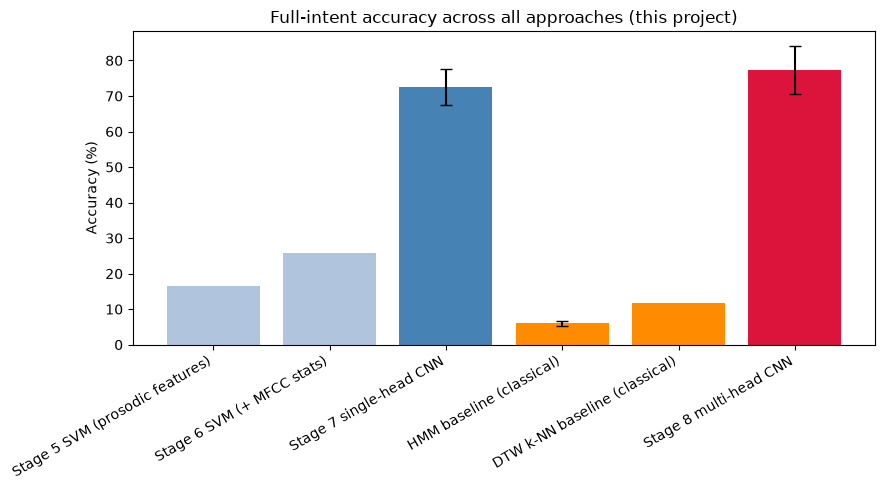

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["lightsteelblue", "lightsteelblue", "steelblue", "darkorange", "darkorange", "crimson"]
bars = ax.bar(summary["Model"], summary["Accuracy_pct"], yerr=summary["Std_pct"], capsize=4, color=colors)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Full-intent accuracy across all approaches (this project)")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
fig.tight_layout()
plt.show()

## Per-slot accuracy (Stage 8 multi-head model)

The individual action, object, and location head accuracies are substantially higher than the full-intent accuracy, since the latter requires all three predictions to be correct simultaneously.

In [4]:
per_slot = multihead_cv[["fold", "action_acc", "object_acc", "location_acc", "full_intent_acc"]]
print(per_slot.to_string(index=False))
print()
print(per_slot[["action_acc", "object_acc", "location_acc", "full_intent_acc"]].mean().round(4))

 fold  action_acc  object_acc  location_acc  full_intent_acc
    1    0.823872    0.899950      0.923256         0.731313
    2    0.785560    0.863916      0.909832         0.676094
    3    0.869529    0.922782      0.948577         0.800300
    4    0.890479    0.945406      0.975033         0.833056
    5    0.893642    0.951565      0.949068         0.823069

action_acc         0.8526
object_acc         0.9167
location_acc       0.9412
full_intent_acc    0.7728
dtype: float64


## Results

The multi-head model achieves a mean full-intent accuracy of 77.3% (std 6.7%) across 5 speaker-grouped folds, an improvement of 4.8 percentage points over Stage 7's single-head model (72.5%, std 5.0%). Individual slot accuracies are substantially higher than the full-intent figure (action 85.3%, object 91.7%, location 94.1% on average), since full-intent accuracy requires all three predictions to be correct simultaneously and errors are not fully independent across heads. The fold-to-fold standard deviation is larger than Stage 7's (6.7 vs. 5.0 percentage points), consistent with a higher-capacity, multi-output model being at least as sensitive to the same small-speaker-count effect identified in Stage 7, not less.

Both classical sequence-classification baselines perform at or below the majority-class baseline (10.4%) on this task: the DTW k-NN baseline reaches 11.6% (evaluated on a stratified subset of one fold, given its computational cost), and the corrected HMM baseline reaches only 5.96% (std 0.73% across 5 folds) -- confirmed not to be a numerical artifact, but a genuine limitation of a simple 3-state, single-Gaussian-per-state, per-class generative model applied directly to raw MFCC frames without further engineering (e.g. more states, mixture emissions, or class-balanced likelihood calibration). This is a stark, honestly-obtained comparison point: on identical features, deep sequence models outperform these classical sequence-classification approaches by a factor of roughly 7-13x, not because the classical approaches were given an unfair implementation, but because bringing them to competitive performance would require substantially more classical modeling sophistication than a first-pass implementation provides -- itself a meaningful finding for the classical-vs-learned comparison this stage set out to make.

Combining Stages 5 through 8, the overall trajectory is: prosodic-only static features (16.5%) -> adding richer spectral content via MFCC statistics (25.8%) -> reintroducing temporal order via a sequence model (72.5%) -> decomposing the output into the corpus's native per-slot structure (77.3%). Each step's improvement is directly attributable to addressing a specific, previously-identified limitation of the step before it, and each has been evaluated with a methodology (speaker-grouped cross-validation, from Stage 7 onward) verified to be reliable given this corpus's small per-split speaker counts.